###### Step1 : Prepare the environment and import packages 


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import validation_curve
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from time import sleep, time


###### Step2 : Data preparation and visualization
MNIST data set (train and test csvs were downloaded and stored in current folder structure)

In [2]:
train_data = pd.read_csv("train.csv/train.csv") #reading the csv files using pandas
test_data = pd.read_csv("test.csv/test.csv")

###### Step3 : Visualize the datasets

In [3]:
print("training data shape" , train_data.shape)
print("testing  data shape" , test_data.shape)
train_data.describe()
#test_data.describe()

training data shape (42000, 785)
testing  data shape (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [4]:
order = list(np.sort(train_data['label'].unique()))
print(order)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Visualization of a sample digit in dataset

Text(0.5, 1.0, 'Digit 4')

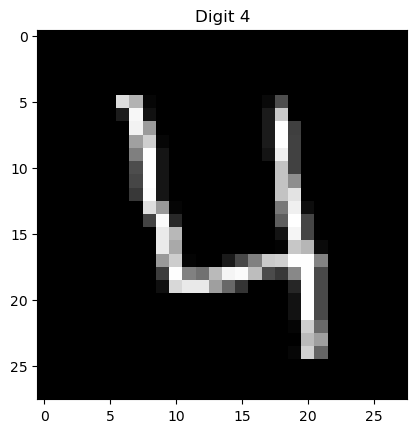

In [5]:
four = train_data.iloc[3, 1:]
four.shape
four = four.values.reshape(28,28)
plt.imshow(four, cmap='gray')
plt.title("Digit 4")

###### Separate out X and Y from training data

In [6]:
y = train_data['label']

## Dropping the variable 'label' from X variable 
X = train_data.drop(columns = 'label')

## Printing the size of data 
print(train_data.shape)

(42000, 785)


###### Now, lets normalize the data

In [7]:
X = X/255.0
test_data = test_data/255.0

print("X:", X.shape)
print("test_data:", test_data.shape)

X: (42000, 784)
test_data: (28000, 784)


###### Lets scale the data using sklearn library

In [8]:
from sklearn.preprocessing import scale
X_scaled = scale(X)

###### Now, we will split train and test data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, train_size = 0.2 ,random_state = 10)

###### Now we will build a SVM model using train and test data

In [10]:
non_linear_model = SVC(kernel='rbf')

# fit
non_linear_model.fit(X_train, y_train)

# predict
y_pred = non_linear_model.predict(X_test)
st = time()

model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

# predict
y_pred = model_linear.predict(X_test)

Model buliding is done now. We will test and print the accuracy of this model. 

In [11]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix
# accuracy
print("accuracy:", metrics.accuracy_score(y_true=y_test, y_pred=y_pred), "\n")

# cm
print(metrics.confusion_matrix(y_true=y_test, y_pred=y_pred))
#print("support vectors" , model_linear.support_vectors_.shape)
#print("class wieghts" , model_linear.coef_)

accuracy: 0.9133333333333333 

[[1160    0    0    1    6    6   12    1    1    1]
 [   0 1389    3    4    3    0    0    2   12    0]
 [   9   11 1146   38   11    4   10   12   17    2]
 [   5    4   35 1204    0   51    2    3   21    6]
 [   3    3   20    3 1132    1   10    4    2   40]
 [   9   17   10   67    7  997   14    2   19    7]
 [  15    2   15    0    9   15 1160    1    2    0]
 [   5   12   18    9   26    2    1 1212    3   42]
 [   8   31   24   45    8   61    9   14 1002   15]
 [   9    6    7   28   56    3    0   53    7 1106]]


###### Hyper parameter tuning to find best set of parameters for enhanced accuracy. 

In [12]:
# creating a KFold object with 5 splits 
folds = KFold(n_splits = 2, shuffle = True, random_state = 10)

# specify range of hyperparameters
# Set the parameters by cross-validation
hyper_params = [ {'gamma': [1e-2, 1e-3],
                     'C': [5,10]}]


# specify model
model = SVC(kernel="rbf")

# set up GridSearchCV()
model_cv = GridSearchCV(estimator = model, 
                        param_grid = hyper_params, 
                        scoring= 'accuracy', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True)      

# fit the model
model_cv.fit(X_train, y_train)

best_score = model_cv.best_score_
best_hyperparams = model_cv.best_params_
print("The best test score is {0} corresponding to hyperparameters {1}".format(best_score, best_hyperparams))


Fitting 2 folds for each of 4 candidates, totalling 8 fits
The best test score is 0.9346428571428571 corresponding to hyperparameters {'C': 5, 'gamma': 0.001}


###### Now lets train the best model using best hyper params obtained above.

In [13]:
model = SVC(C=10, gamma=0.001, kernel="rbf")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# metrics
print("accuracy", metrics.accuracy_score(y_test, y_pred), "\n")
print(metrics.confusion_matrix(y_test, y_pred), "\n")

pet = time() - st
print("Serial Execution Time: ", pet)


accuracy 0.9438888888888889 

[[1163    0    4    1    1    2    8    6    3    0]
 [   0 1389    4    2    4    0    1    9    4    0]
 [   1    4 1184   14    5    1    9   30    7    5]
 [   0    3   15 1263    0   14    2   23    8    3]
 [   1    2   20    3 1149    0   10   10    2   21]
 [   2    8    3   30    4 1064   15    9   11    3]
 [   8    1    3    0    3   13 1167   23    1    0]
 [   4    9   10    8   12    0    0 1255    2   30]
 [   5   18   17   23    8   20    5   13 1098   10]
 [   5    3    2   27   21    1    1   51    3 1161]] 

Serial Execution Time:  154.49476623535156


#### So with sequential approach for SVC classifier development for MNIST DB is : 154.495 seconds whereas accuracy is 0.943


# Now we will move towards parallelization. 
Following steps will be followed to achieve parallelization and cascaded affect : 

Methodology : 
We will use JOBLIB library to achieve parallel programming. 
JOBLIB provides Parallel construct to create parallel worker processes.   

Shared Memory Model :
Shared memory will be created and input data set would be copied to it. So that each parallel worker will have 
access to input data set. 

Data Parallelization and training methodology: 
Out of total MNIST dataset which contains 60000 samples, 42000(70%)will be used. 
This 42000 samples will be divided in 10 equal size (42000/10 = 4200) segmented data sets. 
10 parallel worker processes will be created to train SVC classifier on segmented data set. 
Result would be cascaded. 

Parallelized Grid Search :
In order to find best set of hyper params, Grid search with 4 parallel jobs would be done. 



# Steps : 
1) Import required environment like Multiprocessing, Shared Memory and Joblib
2) Create shared memory for Training data X MyMemory_X and output labels y MyMemory_Y. 
3) Copy input data to Shared memory 
4) create utility function train_svc_parallel, this will be called by parallel workers. 
5) Find number of CPU cores available and limit within them.
6) Using Parallel construct of joblib, call train_svc_parallel with index ranging from 0 to 9, referring each segmented data set. 
7) Receive the output and find support vectors.
8) Perform parallelized grid search. 
9) Print accuracy and total execution time. 
10) Merge the Support vectors of each of the models and re-train the model. 

In [14]:
from joblib import Parallel, delayed

from PIL import ImageDraw, Image
import numpy as np
from numpy import ndarray
from pathlib import Path
from multiprocessing import cpu_count
from multiprocessing import shared_memory
from multiprocessing.shared_memory import SharedMemory

print("starting")

# creating a KFold object with 5 splits
def Grid_Search_parallel(jobs):
    folds = KFold(n_splits = 2, shuffle = True, random_state = 10)

# specify range of hyperparameters
# Set the parameters by cross-validation
    hyper_params = [ {'gamma': [1e-2, 1e-3],
                     'C': [5,10]}]


# specify model
    model = SVC(kernel="rbf")

# set up GridSearchCV()
    model_cv = GridSearchCV(estimator = model, 
                        param_grid = hyper_params, 
                        scoring= 'accuracy', 
                        cv = folds, 
                        verbose = 0,
                        return_train_score=True,
                        n_jobs=jobs)      

# fit the model
    model_cv.fit(X_train, y_train)

    best_score = model_cv.best_score_
    best_hyperparams = model_cv.best_params_
    print("The best test score is {0} corresponding to hyperparameters {1}".format(best_score, best_hyperparams))
    return best_score

def train_svc_parallel(idx , save_dir):
    
    sm_X  = SharedMemory('MyMemory_X')
    sm_Y  = SharedMemory('MyMemory_Y')
    str1 = str(sm_X) + str(sm_Y)
    str1 

    ##create numpy arrays with shared buffers
    n = 42000*784
    m = 42000

    data_X1 = ndarray(shape=(42000*784), dtype=np.float64, buffer=sm_X.buf)
    data_Y = ndarray((m,), dtype=np.float64, buffer=sm_Y.buf)
    data_X = data_X1.reshape(42000 , 784)
    start = idx * 4200
    seg_X = data_X[start:start+4200, 0:784]
    seg_Y = data_Y[start:start+4200]
    #return seg_Y.shape
    
    X_train, X_test, y_train, y_test = train_test_split(seg_X, seg_Y, test_size = 0.3, train_size = 0.2 ,random_state = 10)
    model = SVC(kernel='linear')
    model.fit(X_train, y_train)
    return model

start_time = time()

save_dir_parallel_process = Path('./parallel_process')
save_dir_parallel_process.mkdir(parents=True, exist_ok=True)

start_time = time()

print("Number of jobs: ",int(cpu_count()))

# Use multiple CPUs (Multi Processing)
#divide training data : 42000 samples : in 7 equal sizes 
#seg_data_x = segment_data_X(X_scaled , 7)
#y_np = y.to_numpy()
#seg_data_y = segment_data_Y(y_np , 7)


##create shared memory to copy input data for X
sm_X = SharedMemory(name='MyMemory_X', create=True, size=42000*784*64)
sm_Y = SharedMemory(name='MyMemory_Y', create=True, size=42000*64)

##create numpy arrays with shared buffers
n = 42000*784
m = 42000

data_X1 = ndarray(shape=(42000*784), dtype=np.float64, buffer=sm_X.buf)
data_Y = ndarray((m,), dtype=np.float64, buffer=sm_Y.buf)
data_X = data_X1.reshape(42000 , 784)
print("data_X" , data_X.shape , data_X1.shape)

##copy the data to shared mem buffers
##copy X data
for row in range(42000):
    for col in range(784):
        data_X[row][col] = (np.float64)(X_scaled[row][col])

##copy y data        
for row in range(42000):
    data_Y[row] = y[row]

print("before modelling")

models = Parallel(n_jobs=int(1), prefer='processes')(
    delayed(train_svc_parallel)(idx , save_dir=save_dir_parallel_process) 
    for idx in range(10)
)
#for i in range(1):
#    print("SVC models support vectors" , models[i].support_vectors_.shape)
#    print("SVC models support indices" , models[i].support_ )
score = Grid_Search_parallel(4)
parallel_execution_time = time() - start_time

print("Parallel Execution Time: ", parallel_execution_time , "Accuracy in parallelized approach : ", score)
merged_SV_X = ndarray(shape=(1,784), dtype=np.float64)
merged_SV_Y = ndarray(shape=(1), dtype=np.float64)

for i in range(10):
    #print(models[i].support_vectors_.shape[0])
    #print(models[i].support_vectors_[0])
    for j in range(models[i].support_vectors_.shape[0]):
        merged_SV_X = np.append(merged_SV_X, [models[i].support_vectors_[j]], axis=0)
        merged_SV_Y = np.append(merged_SV_Y, [y[models[i].support_[j]]], axis=0)
        
#print(merged_SV_Y.shape)
#print(merged_SV_X.shape)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, train_size = 0.2 ,random_state = 10)
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

sm_X.close()
sm_X.unlink()
sm_Y.close()
sm_Y.unlink()

starting
Number of jobs:  12
data_X (42000, 784) (32928000,)
before modelling
The best test score is 0.9346428571428571 corresponding to hyperparameters {'C': 5, 'gamma': 0.001}
Parallel Execution Time:  92.18312931060791 Accuracy in parallelized approach :  0.9346428571428571


###### SV CASCADING 
We have trained 10 Support vector classifiers on 10 different cores.
After completion of above step, we have 10 classifiers. We will now merge then and have much smaller set of SVs. 

#### So with parallel approach (using cascading) for SVC classifier development for MNIST DB is : 92.183 seconds whereas accuracy is 0.934


# SUMMARY : 

WITH Sequential Approach : 
Total Execution time  = 154.495 seconds 
Accuracy of the Model = ~94%

WITH Shared Mem and Parallelized Approach : 
Total Execution time  = 92.183 seconds 
Accuracy of the Model = ~93%

So, its quite obvious that sequential approach is much slower than compared to P-SVC with cascading. 